<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fli_loy/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [3]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1077/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1077/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

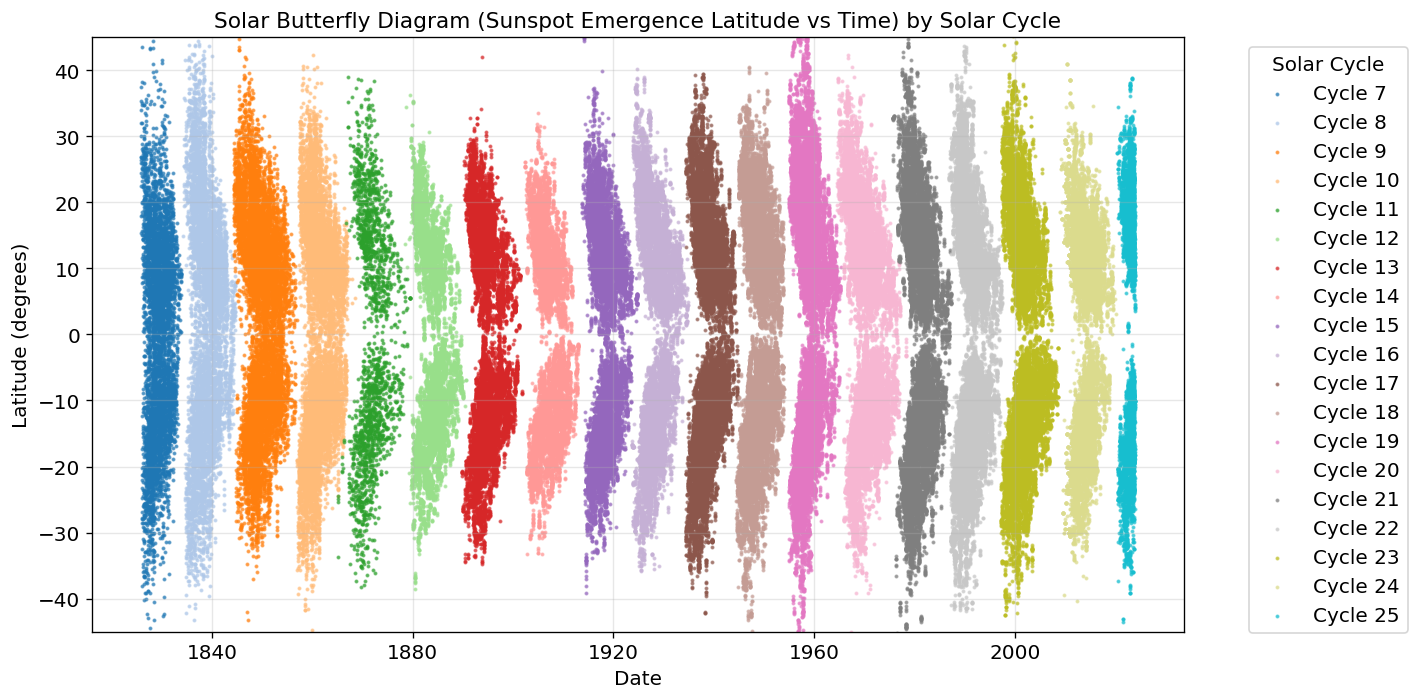

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Drop rows where 'CYCLE' is NaN for plotting discrete cycles
df_cycles = df.dropna(subset=['CYCLE']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

# Get unique cycles and create a colormap
unique_cycles = sorted(df_cycles['CYCLE'].unique())
colors = plt.colormaps.get_cmap('tab20') # Removed the second argument

for i, cycle in enumerate(unique_cycles):
    cycle_group = df_cycles[df_cycles['CYCLE'] == cycle]
    ax.scatter(cycle_group['date'], cycle_group['latitude'], s=2, c=[colors(i)], label=f'Cycle {int(cycle)}', alpha=0.6)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) by Solar Cycle")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Solar Cycle", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(-45, 45)
plt.tight_layout()
plt.show()

## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


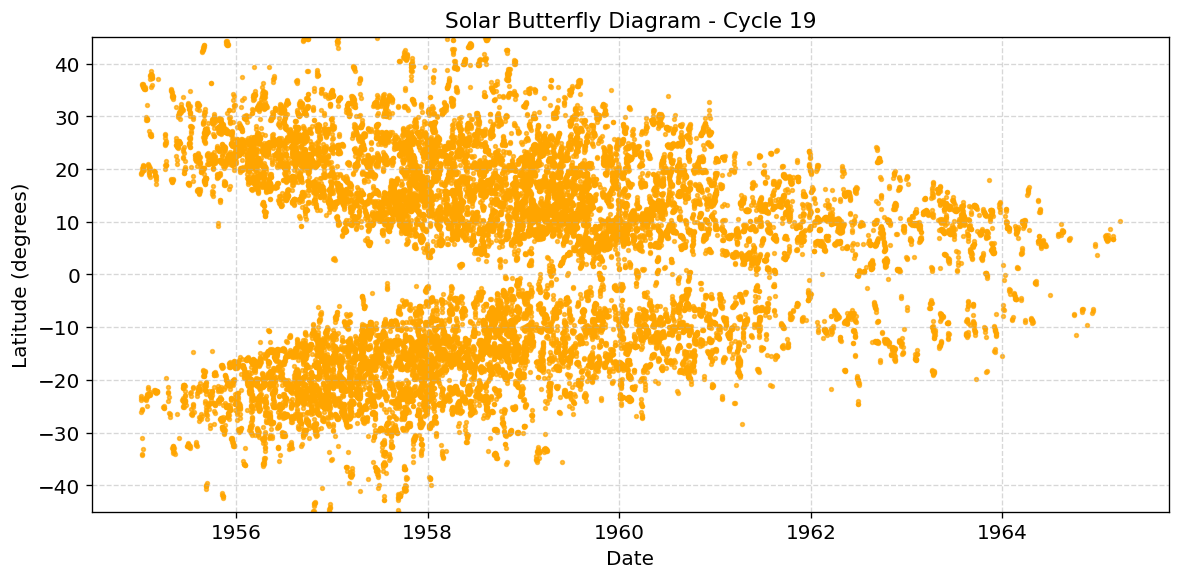

In [6]:
#coded by on-site Gemini
import matplotlib.pyplot as plt

# Filter the data for Cycle 24
cycle_19 = df[df['CYCLE'] == 19].copy()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(cycle_19['date'], cycle_19['latitude'], s=5, alpha=0.7, color='orange')

# Formatting
ax.set_title("Solar Butterfly Diagram - Cycle 19")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_1077/2810225138.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mean_paths = df.groupby(['hemisphere', pd.Grouper(key='date', freq='1Y')])['latitude'].mean().reset_index()


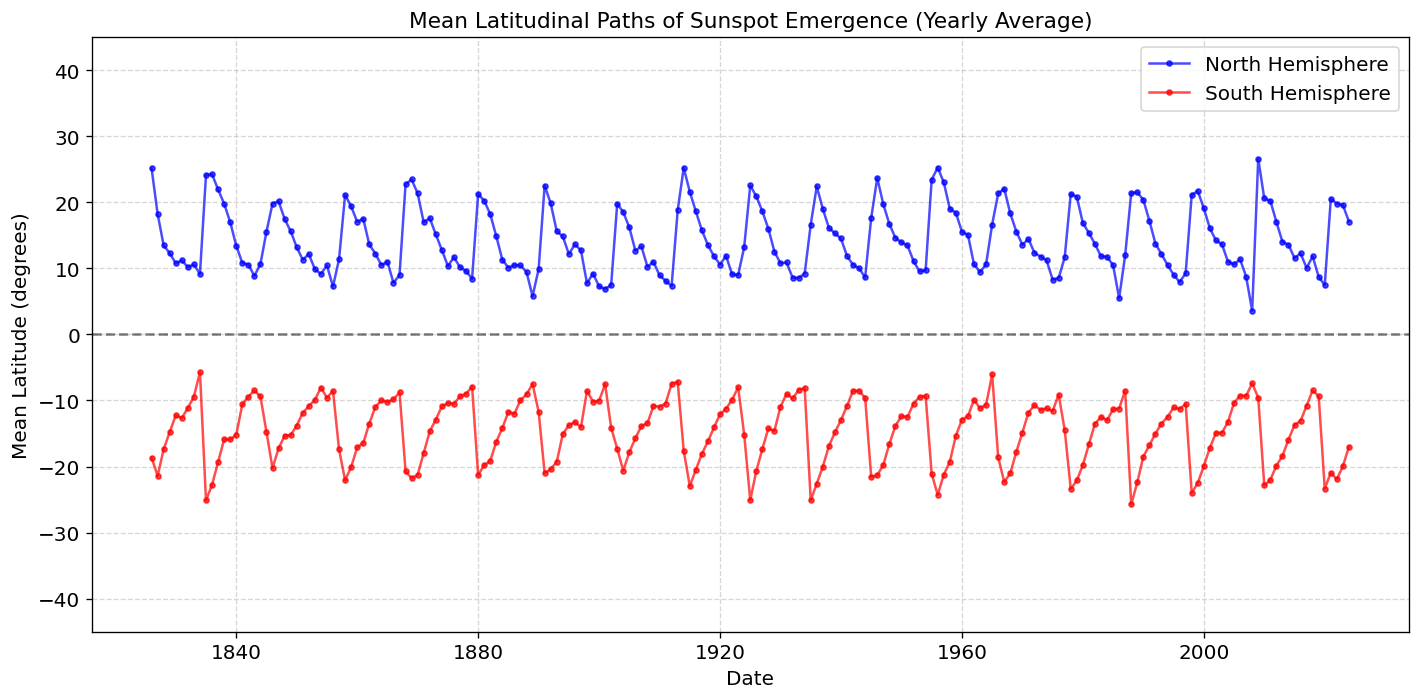

In [7]:
#coded on-site by Gemini
import matplotlib.pyplot as plt
import pandas as pd

# Create hemisphere column
df['hemisphere'] = df['latitude'].apply(lambda x: 'North' if x >= 0 else 'South')

# Group by hemisphere and year, then calculate the mean latitude
# pd.Grouper allows us to group by a time frequency (e.g., '1Y' for 1 year) on the date column
mean_paths = df.groupby(['hemisphere', pd.Grouper(key='date', freq='1Y')])['latitude'].mean().reset_index()

# Separate the data for plotting
north_path = mean_paths[mean_paths['hemisphere'] == 'North']
south_path = mean_paths[mean_paths['hemisphere'] == 'South']

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(north_path['date'], north_path['latitude'], label='North Hemisphere', color='blue', marker='.', linestyle='-', alpha=0.7)
ax.plot(south_path['date'], south_path['latitude'], label='South Hemisphere', color='red', marker='.', linestyle='-', alpha=0.7)

# Formatting
ax.set_title("Mean Latitudinal Paths of Sunspot Emergence (Yearly Average)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude (degrees)")
ax.axhline(0, color='black', linestyle='--', alpha=0.5) # Add equator line
ax.legend()
ax.set_ylim(-45, 45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*
My assistant, Google Gemini, told me about Framework Prompting, which is to "define your current knowledge level, your specific goal, and the pedagogical style you want the AI to adopt." It then goes on to talk about how to properly prompt the AI to give it a specific role so the language it uses will be understandable at one's current knowledge level (i.e. "Act as a research mentor specializing in [Topic, e.g., Heliophysics]. I am a [Level, e.g., undergraduate student] trying to understand [Specific Concept]. Please explain this using an analogy first, then provide the mathematical formulation, and finally show how a [Specific ML Technique] could be used to model it.")

It goes on to talk about using AI to organize a study plan to help learn about heliophysics and emphasizes the use of AI as a learning tool and not as something to replace learning altogether. It speaks about something it calls The "Socratic" Switch, where instead of AI giving all the answers, you instruct it to ask you leading questions so you may come to the conclusion yourself.

Reflecting on this response, I will use the socratic switch method to help advance my knowledge of python instead of having my assistant code the whole thing for me. It is helpful, yes, but ultimately does not help me learn what exactly is happening in the code. (However, I will say that having AI code an easy section for me is very nice, because while I am sure that I would reach a similar code given enough time and thought, having something immediate is a great time-saver)
